# Monte Carlo

- MC (Monte Carlo) je výpočetní metoda založená na generování náhodných čísel.

    - Vzpomeňme si na odhad neurčitosti pomocí pseudoexperimentů z notebooku `10_histogram.ipynb`.

# Příklad: Narozeninový problém

- Narozeninový problém řeší, jaká je pravděpodobnost, že ve skupině `n` osob mají alespoň dvě osoby narozeniny ve stejný den.

- Následující řešení vychází z předpokladu, že rok má 365 dní a narozeniny každé osoby jsou se stejnou pravděpodobností v kterýkoli z nich.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def birthday_coincidence_probability(n, group_size):
    """ Birthday problem for a given group size """
    birthdays = np.random.randint(0, 365, size = (n, group_size))
    unique_counts = np.apply_along_axis(lambda x: len(np.unique(x)), 1, birthdays)
    hits = np.sum(unique_counts < group_size)

    probability = hits / n
    error = np.sqrt(hits) / n

    return probability, error

print(birthday_coincidence_probability(100000, 17)) # (0.3081, np.float64(0.0055506756345511665))
print(birthday_coincidence_probability(10000, 30)) # (0.708, np.float64(0.008414273587185052))

- Nyní vyřešíme narozeninový problém pro velikosti skupin od 2 do 50 a výsledky znázorníme graficky.

In [ ]:
def plot_birthday_problem(n = 10000, group_sizes = range(2, 50)):
    results = np.asarray([birthday_coincidence_probability(n, group_size) for group_size in group_sizes])
        
    probabilities = results[:, 0]
    errors = results[:, 1]

    plt.errorbar(group_sizes, probabilities, yerr = errors)
    plt.title("Birthday problem")
    plt.xlabel(r"$n_{g}$")
    plt.ylabel(r"$p$")
    plt.show()

plot_birthday_problem()


# Jednoduchá MC integrace: Metoda hit-and-miss

- V obrazci o známé ploše (např. obdélník) generujeme náhodné body a počítáme, kolik z nich padne do sledované oblasti pod křivkou funkce, kterou chceme integrovat.

- Integrovanou funkci uzavřeme do obdélníkové oblasti o známých rozměrech. Poměr počtu bodů, které padnou pod křivku, k celkovému počtu vygenerovaných bodů, vynásobený plochou obdélníku, dává odhad integrálu.

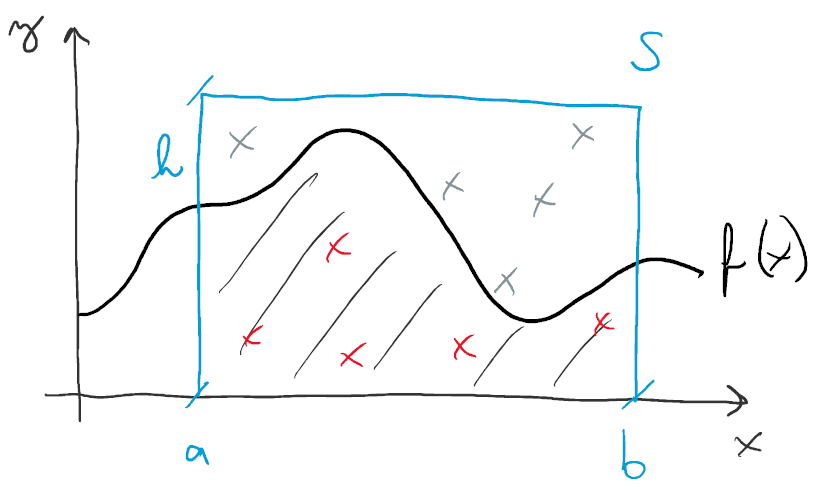

- Algoritmus:

    - Vygenerujeme dvě rovnoměrně rozdělená náhodná čísla $x$ a $y$ v intervalech $[a, b]$ resp. $[0, h]$.

    - Zkontrolujeme, zda $y \leq f(x)$. Pokud ano, zaznamenáme "zásah" (hit).

    - Tento postup opakujeme pro velký počet bodů $N_{\text{total}}$ a spočítáme počet zásahů $N_{\text{hit}}$.

    - Pak:
        $$
        I = \int_{a}^{b}f(x)\mathrm{d} x\approx S\frac{N_{\text{hit}}}{N_{\text{total}}}=(b-a)h\frac{N_{\text{hit}}}{N_{\text{total}}}
        $$

# Neurčitost metody hit-and-miss

- Pozorování: jedinou náhodnou proměnnou ve výše uvedeném vzorci je $N_{\text{hit}}$.

- $N_{\text{hit}}$ se řídí binomickým rozdělením s parametry $N_{\text{total}}$ a $p = I/S$.

- Rozptyl binomického rozdělení je $V[N_{\text{hit}}] = N_{\text{total}} p (1-p)$.

- Rozptyl odhadu integrálu je:
    $$
    V[\hat{I}] = V\left[S\frac{N_{\text{hit}}}{N_{\text{total}}}\right] = \frac{S^2}{N_{\text{total}}^2} V[N_{\text{hit}}] = \frac{S^2}{N_{\text{total}}^2} N_{\text{total}} p (1-p) \sim \frac{1}{N_{\text{total}}}
    $$

- Klíčový poznatek: směrodatná odchylka klesá jako $1/\sqrt{N_{\text{total}}}$.

- Přibližně bychom mohli předpokládat, že $N_{\text{hit}}$ je Poissonova proměnná s rozptylem $V[N_{\text{hit}}] = N_{\text{hit}}$. Rozptyl odhadu integrálu by pak byl:
    $$
    V[\hat{I}] = \frac{S^2}{N_{\text{total}}^2} N_{\text{hit}}
    $$

    To dává stejné škálování směrodatné odchylky jako $1/\sqrt{N_{\text{total}}}$, protože $N_{\text{hit}}$ je úměrné $N_{\text{total}}$.

# Dobrovolná úloha

- Odhadněte plochu jednotkového půlkruhu metodou hit-and-miss. Funkce k integraci je $f(x) = \sqrt{1-x^2}$ a meze integrace jsou $a = -1$ a $b = 1$.

In [ ]:
# Draw the half-circle curve
x = np.linspace(-1, 1, 1000)
y = np.sqrt(1 - x**2)
plt.plot(x, y)
plt.title("Half-circle curve")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

# Metoda hit-and-miss v N rozměrech

- Klíčovou předností metody MC je její jednoduchost. Tato vlastnost se plně projeví při integraci ve vícerozměrném prostoru.

- Jako příklad si spočítejme objem jednotkové koule v n-D prostoru.

In [ ]:
import numpy as np

def volume(tries = 1000000, dimension = 3):
    """Volume of the n-D unit ball calculated by the MC hit-and-miss method
    
    Parameters
    ----------
    tries : int
        Number of random points to generate.
    dimension : int
        Dimension of the space.

    Returns
    -------
    volume : float
        Estimated volume of the n-D unit ball.
    uncertainty : float
        Estimated uncertainty in the volume estimate.
    """

    # Generate random points in the n-D unit cube
    X = np.random.uniform(-1, 1, size = (tries, dimension))
    
    # Check if the points are inside the n-D unit ball
    inside_mask = np.sum(X ** 2, axis = 1) <= 1
    
    # Calculate the volume of the integration region as the volume of the hypercube
    # multiplied by the fraction of points that are inside the region.
    volume = (2 ** dimension) * np.sum(inside_mask) / tries

    # Poisson uncertainty.
    uncertainty = 2 ** dimension * np.sqrt(np.sum(inside_mask)) / tries

    # Binomial uncertainty.
    p = np.sum(inside_mask) / tries
    uncertainty_binomial = 2 ** dimension * np.sqrt(p * (1 - p) / tries)
    
    return volume, uncertainty, uncertainty_binomial

    
volume(tries = 1000000, dimension = 5)

# MC integrace


- Kromě hit-and-miss existuje mnohem efektivnější metoda pro výpočet integrálu, která je vysvětlena na následujícím obrázku:

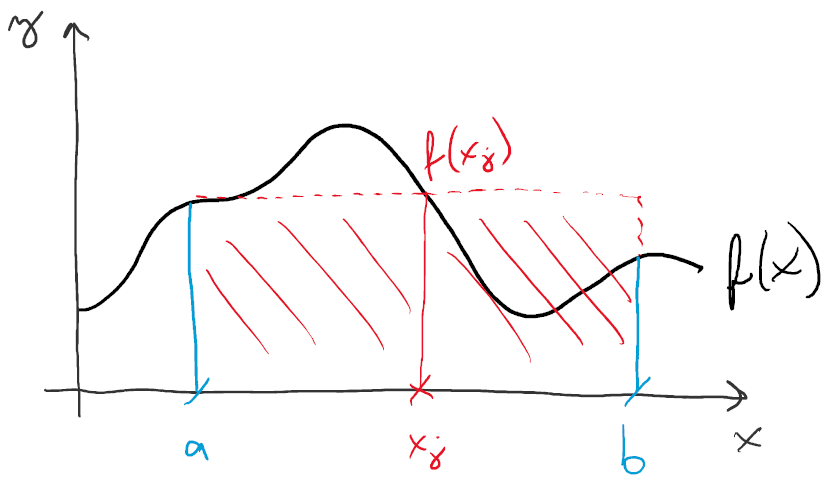

- Nejprve předpokládejme, že známe pouze jeden pár hodnot $(x_{j}, f(x_{j}))$. Na základě těchto hodnot lze udělat jen velmi hrubý odhad integrálu, a sice jako plochu červeně šrafovaného obdélníku,

$$
\int_{a}^{b}f(x)\mathrm{d} x\approx (b-a)f(x_{j}).
$$

Pokud máme více párů hodnot $(x_{j}, f(x_{j}))$, jak je znázorněno na dalším obrázku, bereme průměr ploch takových obdélníků jako odhad integrálu,

$$
\int_{a}^{b}f(x)\mathrm{d} x
    \approx \frac{1}{N}\sum_{j=1}^{N}(b-a)f(x_{j})
    =\frac{b-a}{N}\sum_{j=1}^{N}f(x_{j}).
$$

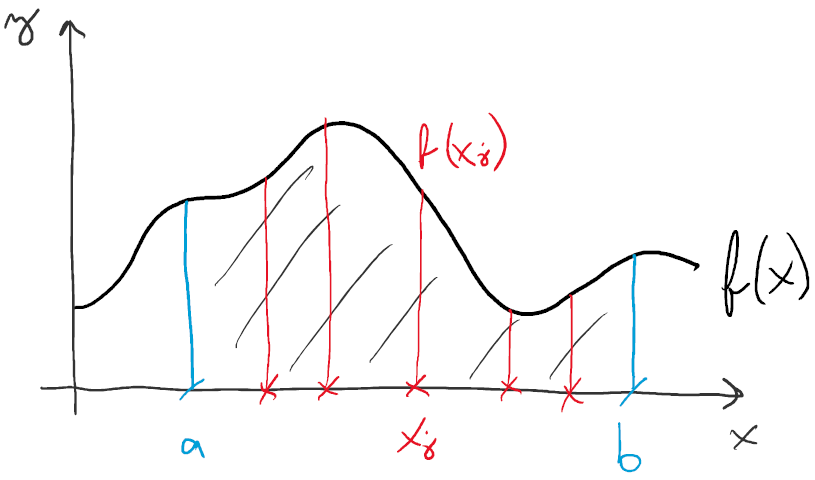

Podstata Monte Carlo integrace spočívá právě v tomto postupu.
Obecně platí, že pokud vybereme hodnoty $x_{j}$ z rozdělení s hustotou pravděpodobnosti $\rho(x)$, odhadneme hledaný integrál výrazem

$$
\int_{a}^{b}f(x)\mathrm{d} x
    \approx\frac{1}{N}\sum_{j=1}^{N}\frac{f(x_{j})}{\rho(x_{j})}.
$$

Tento postup se nazývá `importance sampling` (důležité vzorkování).
V praxi, jelikož funkci nejčastěji považujeme za černou skříňku a nic o jejím chování nevíme, se jako nejvhodnější volba jeví rovnoměrné rozdělení.

Chybu integrační metody lze odhadnout pomocí směrodatné odchylky
\begin{align}
    \Delta\equiv\sigma&=\sqrt{\overline{f}^{2}}-\overline{f}^{2}, \nonumber\\
    \overline{f}^{2}&=\frac{1}{N}\sum_{j=1}^{N}f^{2}(x_{j}), \nonumber\\
    \overline{f}^{2}&=\left[\frac{1}{N}\sum_{j=1}^{N}f(x_{j})\right]^{2}.\nonumber
\end{align}

# Úloha pro vás

- Pomocí metody MC vypočítejte integrály

    \begin{align}
        I_{1}&\equiv\int_{0}^{2\pi}e^{-x}\sin{x}\,\mathrm{d}x,\nonumber\\
        I_{2}&\equiv\int_{0}^{\sqrt{10\pi}}\frac{\sin{x^{2}}}{\sqrt{1+x^{4}}}\mathrm{d}x.\nonumber
    \end{align}

- První integrál má analytické vyjádření, které si můžete odvodit a porovnat s hodnotou získanou metodou MC.

- Druhý integrál lze vypočítat pouze numericky.

- Řešení je níže. Nicméně doporučujeme nejprve zkusit problém vyřešit samostatně.

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def f1(x):
    return np.exp(-x) * np.sin(x)

def f2(x):
    return np.sin(x**2) / np.sqrt(1 + x**4)

def integrate_1D_array(n, function, a, b):
    """ Monte Carlo integration of a 1D function.

    Parameters
    ----------
    n : int
        Number of random samples to draw.
    function : callable
        The function to integrate. It should take a numpy array as input and return a numpy array of the same shape.
    a : float
        The lower bound of the integration interval.
    b : float
        The upper bound of the integration interval.
    """
    x = np.random.uniform(a, b, n)
    result = (b - a) / n * sum(function(x)) 
    return result

print("I1 = {}".format(integrate_1D_array(1000000, f1, 0, 2 * np.pi)))
print("I2 = {}".format(integrate_1D_array(1000000, f2, 0, np.sqrt(10 * np.pi))))

# Integrace v N rozměrech

- Vypočítejte čtyřrozměrný integrál
    $$
        I_{3}\equiv\int_{\Omega}\sin{\sqrt{\ln\left(x+y+z+w+2\right)}}\,\mathrm{d}x\,\mathrm{d}y\,\mathrm{d}z\,\mathrm{d}w,
    $$

    kde integrační oblast je hyperkoule
    $$
        \Omega: \left(x-\frac{1}{2}\right)^{2}+\left(y-\frac{1}{2}\right)^{2}+\left(z-\frac{1}{2}\right)^{2}+\left(w-\frac{1}{2}\right)^{2}\leq\frac{1}{4}.
    $$

- Při řešení nejprve vepište danou hyperkouli do hyperkrychle o známých rozměrech, a tedy o známém objemu $V$.
Pak pro náhodně zvolený bod v hyperkrychli určete, zda leží uvnitř hyperkoule $\Omega$, či nikoli.
Pokud ano, vypočítejte hodnotu integrandu v daném bodě.
Jedná se tedy o kombinaci MC integrace a metody hit-and-miss.
Budete-li sledovat počet hodů $N_{\text{total}}$ a počet zásahů $N_{\text{hit}}$, získáte jako vedlejší produkt objem integrační hyperoblasti.

In [ ]:
import numpy as np

def is_inside_region(X):
    """Returns true if the point X is inside the integration region."""
    x, y, z, w = X.T
    return (x - 0.5)**2 + (y - 0.5)**2 + (z - 0.5)**2 + (w - 0.5)**2 <= 0.25

def f3(X):
    """The function to integrate."""
    x, y, z, w = X.T
    return np.sin(np.sqrt(np.log(x + y + z + w + 2)))

def integral_nd(n, function, is_inside_region, dimension, box_min = 0, box_max = 1):
    """ Monte-Carlo integration of a general-dimensional function.

    Parameters
    ----------
    n : int
        Number of random points to generate.
    function : callable
        The function to integrate. It should take a numpy array of shape (dimension,) as input and return a scalar.
    is_inside_region : callable
        A function that takes a numpy array of shape (dimension,) as input and returns True if the point is inside the integration region, and False otherwise.
    dimension : int
        The number of dimensions of the integration region.
    box_min : float, optional
        The minimum coordinate value (along each axis) for the hypercube that contains the integration region. Default is 0.
    box_max : float, optional
        The maximum coordinate value (along each axis) for the hypercube that contains the integration region. Default is 1.
    """

    # Generate n random points in the hypercube
    X = np.random.uniform(box_min, box_max, size = (n, dimension))

    # Determine which points are inside the region
    inside_mask = is_inside_region(X)

    # Evaluate the function at the points that are inside the region
    function_values = function(X[inside_mask])

    # Calculate the volume of the integration region as the volume of the hypercube
    # multiplied by the fraction of points that are inside the region.
    volume = (box_max - box_min)**dimension * np.sum(inside_mask) / n

    # Calculate the integral as the average of the function.
    integral = np.mean(function_values) * volume

    return integral

# Run the integration and measure the time taken
import time
start_time = time.time()
print(integral_nd(1000000, f3, is_inside_region, dimension = 4))
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Poznámka: vektorizace vs. smyčky

- Výše uvedený kód využívá pouze vektorizované operace, které jsou v Pythonu mnohem rychlejší než smyčky. Mohou však nastat situace, kdy vektorizace není možná, např. pokud integrovanou funkci nelze zapsat pomocí vektorizovaných funkcí (tedy funkcí definovaných v knihovně NumPy). V takových případech je nutné použít smyčky pro vyhodnocení funkce v každém bodě, ale je třeba mít na paměti, že to bude mnohem pomalejší než použití vektorizovaných operací.

- Funkce pro aplikaci obecné funkce na každý řádek 2D pole je `np.apply_along_axis`. Tato funkce spouští smyčku `for`, která je pomalá.

- Kód níže slouží k porovnání rychlosti vektorizovaných operací s rychlostí smyček (pomocí `np.apply_along_axis`). Spusťte ho a podívejte se na rozdíl v době výpočtu.

In [ ]:
# Do the same integration as in the previous cell,
# but using loops instead of vectorized operations,
# to see the difference in execution time.

def integral_nd_loop(n, function, is_inside_region, dimension, box_min = 0, box_max = 1):

    # The generation of random points is the same as in the previous implementation.
    X = np.random.uniform(box_min, box_max, size = (n, dimension))

    # Use the np.apply_along_axis function in this implementation.
    inside_mask = np.apply_along_axis(is_inside_region, 1, X)
    function_values = np.apply_along_axis(function, 1, X[inside_mask])

    # The calculation of the volume and the integral is the same as in the previous implementation.
    volume = (box_max - box_min)**dimension * np.sum(inside_mask) / n
    integral = np.mean(function_values) * volume
    return integral

# Run the integration and measure the time taken
import time
start_time = time.time()
print(integral_nd_loop(1000000, f3, is_inside_region, dimension = 4))
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")